In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# View the first few rows
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


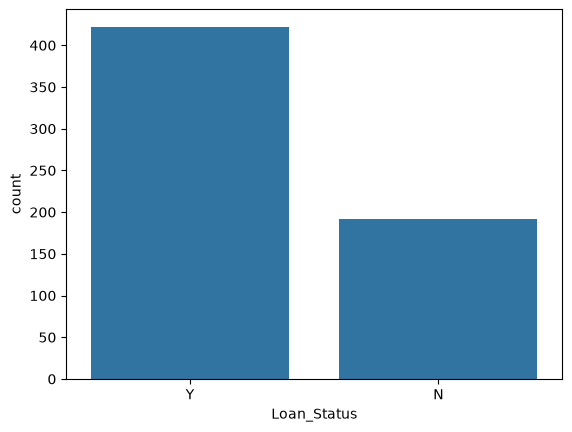

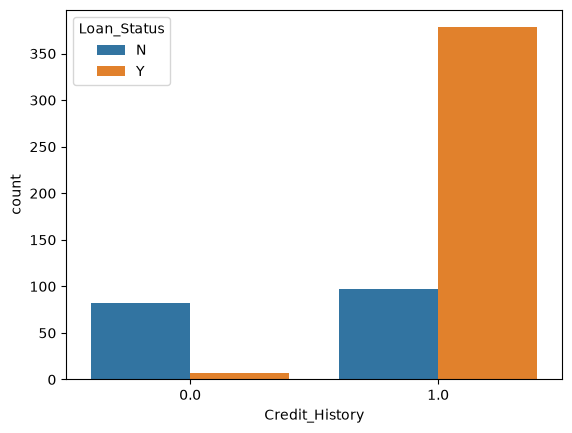

In [30]:
# Check basic statistics
train.describe()

# Check for missing values
train.isnull().sum()

# Visualize the target variable
sns.countplot(x='Loan_Status', data=train)
plt.show()

# Visualize categorical features vs Target
sns.countplot(x='Credit_History', hue='Loan_Status', data=train)
plt.show()

In [32]:
# Filling missing categorical values with mode
train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0])
train['Married'] = train['Married'].fillna(train['Married'].mode()[0])
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].mode()[0])
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0])

# Filling missing numerical values with median or mode
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())

# Check to ensure all missing values are handled
print(train.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [33]:
# Apply log transformation to remove skewness
train['LoanAmount_log'] = np.log(train['LoanAmount'])
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome']
train['TotalIncome_log'] = np.log(train['TotalIncome'])

In [34]:
from sklearn.preprocessing import LabelEncoder
cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
le = LabelEncoder()

for col in cols:
    train[col] = le.fit_transform(train[col])

In [35]:
from sklearn.model_selection import train_test_split

# Drop unnecessary columns and the target variable to create X
X = train.drop(columns=['Loan_ID', 'Loan_Status', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome'])
y = train['Loan_Status'] # Target variable

# Split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = model.predict(X_test)

In [38]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.7642276422764228
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



In [39]:
# ==========================================
# STEP 1: Import Libraries and Load Data
# ==========================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the datasets (ensure the file paths are correct for your Kaggle environment)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Save the Loan_ID from the test set for the final submission file
test_loan_ids = test['Loan_ID']

# ==========================================
# STEP 2: Handle Missing Values (Updated for Pandas 2.0+)
# ==========================================
# We must apply the same imputation to BOTH train and test datasets
datasets = [train, test]

for df in datasets:
    # Fill categorical missing values with Mode
    df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
    df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
    df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
    df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
    df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
    
    # Fill numerical missing values with Mode or Median
    df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
    df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# ==========================================
# STEP 3: Feature Engineering (Handling Skewness)
# ==========================================
for df in datasets:
    # Apply log transformation to normalize heavily skewed data
    df['LoanAmount_log'] = np.log(df['LoanAmount'])
    df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['TotalIncome_log'] = np.log(df['TotalIncome'])

# ==========================================
# STEP 4: Label Encoding (Text to Numbers)
# ==========================================
cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
le = LabelEncoder()

# Encode features in both train and test
for col in cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# Encode the target variable in the training set
train['Loan_Status'] = le.fit_transform(train['Loan_Status']) # Y -> 1, N -> 0

# ==========================================
# STEP 5: Splitting the Training Data for Validation
# ==========================================
# Drop ID, the target variable, and the original un-logged columns
cols_to_drop = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']

X = train.drop(columns=cols_to_drop + ['Loan_Status'])
y = train['Loan_Status']

# Prepare the test data identically
X_test_final = test.drop(columns=cols_to_drop)

# Split the training data to validate our model locally before submitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 6: Model Training and Evaluation
# ==========================================
# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Validate the model
y_val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# ==========================================
# STEP 7: Generate Final Kaggle Submission
# ==========================================
# Predict on the actual test dataset
final_predictions = model.predict(X_test_final)

# Convert numerical predictions (1/0) back to 'Y' and 'N' for Kaggle
final_predictions_text = ['Y' if pred == 1 else 'N' for pred in final_predictions]

# Create the submission DataFrame
submission = pd.DataFrame({
    'Loan_ID': test_loan_ids,
    'Loan_Status': final_predictions_text
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")

Validation Accuracy: 0.7642276422764228

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123


Submission file 'submission.csv' created successfully!


In [3]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features and Target
cols_to_drop = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']

X = train.drop(columns=cols_to_drop + ['Loan_Status'])
y = train['Loan_Status']

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Validation
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

# Save Model
joblib.dump(model, "loan_model.pkl")

print("✅ Model trained and saved as loan_model.pkl")

NameError: name 'train' is not defined